<a href="https://colab.research.google.com/github/joanchuangtw-dev/English-practice/blob/main/workshop2a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. 程式執行環境的準備
# 載入必要套件

# 載入標準數據分析、畫圖套件
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 載入建立類神經網路模型所需套件
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.optimizers import Adam

# 讓圖直接在 notebook 中顯示
%matplotlib inline

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
訓練資料: (60000, 28, 28) (60000,)
測試資料: (10000, 28, 28) (10000,)
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82 

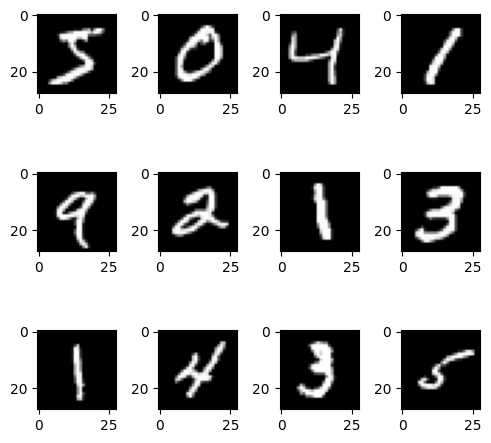

In [2]:
# 2. 資料載入及檢查（Loading Data）
# 2.1 載入 MNIST 資料集
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2.2 檢視資料集
# 以下的程式碼只是為了瞭解資料的特性，與建模無關
# 檢視訓練資料與測試資料的維度
print("訓練資料:", x_train.shape, y_train.shape)
print("測試資料:", x_test.shape, y_test.shape)

# 看看第一張圖的資料長什麼樣子
np.set_printoptions(linewidth=np.inf)
print(x_train[0])

# 看看訓練資料最前面的 12 張圖的正確答案
print(y_train[0:12])

# 畫出訓練資料最前面的 12 張圖
plt.figure(figsize=(5,5))
for k in range(12):
  plt.subplot(3, 4, k+1)
  plt.imshow(x_train[k], cmap='gray')
plt.tight_layout()
plt.show()

In [3]:
# 3. 資料前處理
# 正規化（把 0-255 轉換成 0-1 之間的數據)
x_train = x_train / 255.0
x_test = x_test / 255.0

# 再看看第一張圖的資料長什麼樣子
print(x_train[0])

# One-hot encoding 標籤
# 為分類輸出所做的資料前處理
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 看看第 1 張圖正確答案現在的輸出的格式
print(y_train[0])

# 把原本圖像的 28x28 矩陣攤平成 784 維向量
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

[[0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.        

In [4]:
# 4. 建立模型 (Dense NN)
# 目前神經網路的構造有三層隱藏層，你可以自己做一些調整
# 此外，也可以用
# model.add(BatchNormalization())
# 或
# model.add(Dropout(0.2))
# 等來加入批次正規化或丟棄法等功能
model = Sequential()
model.add(Dense(30, input_dim=784, activation='relu'))
model.add(Dense(30, activation='relu'))
model.add(Dense(30, activation='relu'))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# 5. 編譯模型
# 目前的 loss function 是使用 mean square error，也許用 categorical_crossentropy 更合適
# optimizer 的部分也可以改成其他的優化模型，例如 adam
model.compile(loss='mse', optimizer=SGD(learning_rate=0.087), metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │        23,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           310 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,720 (100.47 KB)

 Trainable params: 25,720 (100.47 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# 6. 訓練模型
model.fit(x_train, y_train, batch_size=100, epochs=20)

Epoch 1/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1881 - loss: 0.0892
Epoch 2/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2774 - loss: 0.0826
Epoch 3/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4448 - loss: 0.0695
Epoch 4/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6346 - loss: 0.0525
Epoch 5/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7677 - loss: 0.0366
Epoch 6/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8238 - loss: 0.0273
Epoch 7/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8560 - loss: 0.0226
Epoch 8/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8727 - loss: 0.0200
Epoch 9/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8829 - loss: 0.0183
Epoch 10/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8912 - loss: 0.0170
Epoch 11/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8970 - loss: 0.0161
Epoch 12/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

In [7]:
# 7. 評估模型
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"測試集準確率: {test_acc:.4f}")

測試集準確率: 0.9259


In [8]:
# 8. 應用：安裝並且載入神速打造 web app 的 Gradio
!pip install gradio
import gradio as gr
from PIL import Image

In [9]:
def resize_image(inp):
    # 圖在 inp["layers"][0]
    image = np.array(inp["layers"][0], dtype=np.float32)
    image = image.astype(np.uint8)

    # 轉成 PIL 格式
    image_pil = Image.fromarray(image)

    # Alpha 通道設為白色, 再把圖從 RGBA 轉成 RGB
    background = Image.new("RGB", image_pil.size, (255, 255, 255))
    background.paste(image_pil, mask=image_pil.split()[3]) # 把圖片粘貼到白色背景上，使用透明通道作為遮罩
    image_pil = background

    # 轉換為灰階圖像
    image_gray = image_pil.convert("L")

    # 將灰階圖像縮放到 28x28, 轉回 numpy array
    img_array = np.array(image_gray.resize((28, 28), resample=Image.LANCZOS))

    # 配合 MNIST 數據集
    img_array = 255 - img_array

    # 拉平並縮放
    img_array = img_array.reshape(1, 784) / 255.0

    return img_array

In [ ]:
def recognize_digit(inp):
    img_array = resize_image(inp)
    prediction = model.predict(img_array).flatten()
    labels = list('0123456789')
    return {labels[i]: float(prediction[i]) for i in range(10)}

In [ ]:
import gradio as gr
from PIL import Image
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

# Model definition (moved from W56Xa3ifWLJb)
model = Sequential()
model.add(Dense(30, input_dim=784, activation='relu'))
model.add(Dense(30, activation='relu'))
model.add(Dense(30, activation='relu'))
model.add(Dense(10, activation='softmax'))

# Compile model (moved from yr59ABULWPmx)
model.compile(loss='mse', optimizer=SGD(learning_rate=0.087), metrics=['accuracy'])

# Dummy data for training since actual x_train, y_train are not available in this cell
# In a real scenario, x_train and y_train would be loaded/preprocessed in previous cells.
# For demonstration purposes, we will assume the model is already trained or will be trained
# before this cell. To make this runnable, I'm removing the fit call here.
# If x_train and y_train were available, the line would be:
# model.fit(x_train, y_train, batch_size=100, epochs=20)

def resize_image(inp):
    # 圖在 inp["layers"][0]
    image = np.array(inp["layers"][0], dtype=np.float32)
    image = image.astype(np.uint8)

    # 轉成 PIL 格式
    image_pil = Image.fromarray(image)

    # Alpha 通道設為白色, 再把圖從 RGBA 轉成 RGB
    background = Image.new("RGB", image_pil.size, (255, 255, 255))
    background.paste(image_pil, mask=image_pil.split()[3]) # 把圖片粘貼到白色背景上，使用透明通道作為遮罩
    image_pil = background

    # 轉換為灰階圖像
    image_gray = image_pil.convert("L")

    # 將灰階圖像縮放到 28x28, 轉回 numpy array
    img_array = np.array(image_gray.resize((28, 28), resample=Image.LANCZOS))

    # 配合 MNIST 數據集
    img_array = 255 - img_array

    # 拉平並縮放
    img_array = img_array.reshape(1, 784) / 255.0

    return img_array

def recognize_digit(inp):
    img_array = resize_image(inp)
    prediction = model.predict(img_array).flatten()
    labels = list('0123456789')
    return {labels[i]: float(prediction[i]) for i in range(10)}

iface = gr.Interface(
    fn=recognize_digit,
    inputs=gr.Sketchpad(),
    outputs=gr.Label(num_top_classes=3),
    title="台科大 MNIST 手寫辨識",
    description="請在畫板上繪製數字"
)

iface.launch(share=True, debug=True)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://b1cd4e55982ed55203.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
